# Свёрточная нейронная сеть. Часть 1

Технологии машинного обучения сделали большой шаг вперед в работе с
цифровыми изображениями. В частности, сегодня сложно удивить возможностями
по классификации изображений (image classification) или обнаружению объектов
(object detection). Более интересным вопросом является то, как именно модели ML
показывают такую высокую точность при решении задач компьютерного зрения.

Ключевым инструментом в этой области является так называемая свёрточная
нейронная сеть (convolutional neural network, CNN, а также ConvNet).

## Задачи компьютерного зрения

Вначале опишем основные задачи компьютерного зрения (computer vision). Так
мы будем лучше понимать, для каких целей можно использовать свёрточную
нейронную сеть.
![](https://drive.google.com/uc?export=view&id=1ttKH-hNqvwupo8a2sNJw9_5c1ttMQDFg)

Наиболее общей задачей является распознавание объекта (object recognition), то
есть понимание или анализ компьютером того, что представлено на цифровом
изображении или на видео.

Внутри этой общей задачи стоят подзадачи классификации (object classification),
то есть отнесения объекта к определенному классу, и локализации (object
localization) или указания (с помощью рамки) положения объекта на изображении.
**Обнаружение объекта** (object detection) предполагает как классификацию, так и
локализацию объекта. В то же время на этом этапе мы не можем ничего сказать о
площади или, например, периметре объекта. Для решения этой задачи необходимо
выполнить сегментацию изображения (image segmentation), то есть разделение
изображения на отдельные области с выделенными границами.

Добавим, что задачи компьютерного зрения решаются не только алгоритмами
глубокого обучения, но и с помощью классического ML. В качестве примера можно
привести метод Виолы-Джонса (Viola-Jones method) для обнаружения лиц.
## Полносвязные нейросети
Посмотрим, почему не стоит применять «обычные» полносвязные нейросети для
работы с изображениями.

Переобучение. Вспомним, что когда мы предсказывали рукописные цифры из
датасета MNIST, архитектура применяемой нами полносвязной нейронной сети
состояла из входного, двух скрытых и одного выходного слоя.

Каждое изображение в этом наборе данных имело размерность 28 на 28 пикселей,
что при «вытягивании» давало 784 нейрона входного слоя. Каждый скрытый слой
состоял из 64 нейронов и наконец выходной слой насчитывал 10 нейронов по числу
цифр или классов. Всего даже при использовании таких небольших изображений
получалось 55 050 параметров.

Помимо вычислительной затратности алгоритма такое количество нейронов и
параметров модели способствует её переобучению.

**Сохранение структуры изображения.** Еще один повод отказаться от
полносвязной архитектуры заключается в том, что в отличие от, например, задачи
предсказания цены квартиры по ее параметрам, где, скажем район, скорее всего, не
коррелирует с количеством комнат, в изображениях расположенные рядом пиксели
(вспомним, что пиксели являются признаками) связаны между собой.

В самом деле, если на картинке изображена рыжая кошка, то вероятность того, что
рядом с «рыжим» пикселем будет пиксель такого же оттенка выше, чем
вероятность пикселя другого цвета. Таким образом, «вытягивая» матрицу картинки,
мы уничтожаем то, что называется пространственной структурой (spatial
structure) изображения.

**Пространственная инвариантность.** Добавим, что поскольку полносвязная сеть
запоминает каждый пиксель отдельно, то она будет ожидать, что кошка всегда
расположена в определенной части изображения. При этом мы понимаем, что в
реальности объект может находиться в любой части картинки. Говорят, что
полносвязная нейросеть не обладает пространственной инвариантностью (spatial
invariance).

Именно эти недостатки полносвязной архитектуры и призвана преодолеть
свёрточная нейронная сеть.

## Дискретная свёртка
### Операция свёртки
Начнем с не связанного с компьютерным зрением и нейросетями примера.
Предположим, что вы работаете в больнице, и к вам на амбулаторное лечение
приходят пациенты, каждому из которых нужно дать по три таблетки лекарства.

Предположим, что в течение пяти дней к вам приходит 1, 2, 3, 4 и 5 пациентов.
![](https://drive.google.com/uc?export=view&id=1DN6M8AWQUbtAJvqLWHX1-46VE9bSSkI7)

Поставим задачу рассчитать, какое количество препарата потребуется в каждый из
приемных дней. Вполне очевидно, что достаточно умножить (обозначим такое
умножение через ∗) три таблетки на количество пациентов в каждый из дней
лечения.

3 ∗ [ 1, 2, 3, 4, 5 ] = [ 3, 6, 9, 12, 15 ]

Теперь допустим, что план лечения изменился и каждому пациенту необходимо в
первый день дать три таблетки, во второй — две, а в третий — одну.

[ 3, 2, 1 ] ∗ [ 1, 2, 3, 4, 5 ]

Другими словами, в понедельник придет один пациент и получит три таблетки, во
вторник придут еще два пациента и тоже получат три таблетки, а первый пациент
получит уже две таблетки. Таким образом, в первый день потребуется $1 \cdot 3 =
3$ единицы препарата, а во второй $1 \cdot 2 + 2 \cdot 3 = 8$ единиц препарата.
Очевидно, что с течением времени вести учет потребности в лекарстве становится
довольно сложно.

Попробуем упростить расчеты следующим образом. Разместим элементы списка
пациентов в обратном порядке, т.е. [ 5, 4, 3, 2, 1 ], а список с количеством таблеток
разместим над ним таким образом, чтобы, например, в первый день пришедший пациент соответствовал трем необходимым ему таблеткам.

            [3, 2, 1]
[5, 4, 3, 2, 1]

Перемножим количество пациентов и количество таблеток и получим потребность
в лекарстве в понеделник, $1 \cdot 3 = 3.$ Далее сдвинем список пациентов на одно значение вправо.

          [3, 2, 1]
[5, 4, 3, 2, 1] $\rightarrow$

Просуммируем те значения обоих списков, которые находятся друг над другом и
сложим результат, $1 \cdot 2 + 2 \cdot 3 = 8.$ Продолжая сдвигать таким же образом список пациентов, мы получим, что потребность в препарате составляет

![](https://drive.google.com/uc?export=view&id=1cQmx8Nu3uzL8euf6VUtpvgceu9wiQU-S)

В субботу и в воскресенье потребность в препарате возникает из-за того, что
пришедшие в пятницу пациенты будут проходить трехдневный курс лечения.

Описанную выше операцию назовем (дискретной) свёрткой или конволюцией
(convolution) и обозначим через оператор $\ast.$ Таким образом,

[ 3, 2, 1 ] ∗ [ 1, 2, 3, 4, 5 ] = [ 3, 8, 14, 20, 26, 14, 5 ]

Математически операцию свёртки можно задать следующим образом. Введем
функцию $f(x),$ определяющую количество лекарства, а также функцию $g(−x+t),$
определяющую количество пациентов в каждый из дней лечения.

Визуально аргумент $g(-x+t)$ подразумевает, что мы отражаем g относительно оси
ординат $-x$ и сдвигаем на $+t$ вправо в зависимости от того, для какого дня мы
хотим рассчитать количество препарата.

Общая формула будет иметь вид

$$ (f \ast g)[t] = \sum^{\infty}_{x=-\infty} f(x) \cdot g(-x+t) $$

Заметим, что чаще вместо $g(-x+t)$ пишут $g(t-x).$

Границы суммирования идут от $-\infty$ до $\infty,$ чтобы учесть все возможные
значения аргумента. Для функций с конечным носителем, т.е. конечным
подмножеством области определения, на котором функция отлична от нуля (как в
нашем случае) мощность носителя свёртки определяется по формуле

$$ N+M-1,$$

где $N$ — мощность носителя функции $f,$ а $M$ — мощность носителя $g.$
Таким образом, в нашем примере $N = 3,$ $M = 5$ и мощность носителя свёртки
будет равна $3+5-1=7.$

В Питоне свёртку одномерных массивов можно выполнить с помощью функции
**np.convolve()**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

##Коммутативность свёртки

Несложно увидеть, что операция свертки коммутативна. Если мы зафиксируем
список пациентов и перевернем и будем сдвигать план лечения, то результат не
изменится.

      [1, 2, 3, 4. 5]
[1, 2, 3] $\rightarrow$


## Дискретная свёртка

Свёртка одномерных массивов

In [2]:
drugs, patients = np.array([3,2,1]), np.array([1,2,3,4,5])
np.convolve(drugs, patients)

array([ 3,  8, 14, 20, 26, 14,  5])

In [3]:
np.convolve(patients, drugs)

array([ 3,  8, 14, 20, 26, 14,  5])

Таким образом,
$$ f \ast g = g \ast f $$

## Свёртка двумерных массивов
Перейдем к двумерным массивам и сразу начнем говорить про изображения. Ведь,
как мы помним, цифровое черно-белое изображение представляет собой матрицу
(двумерный массив), в которой значения каждого элемента указывают на
интенсивность оттенка серого. Оттенки находятся в диапазоне от 0 (черный) до 255
(белый).

Рассмотрим следующее небольшое изображение размером 6 x 6 пикселей.
![](https://drive.google.com/uc?export=view&id=1m1kgpVWSoLSidoC5w1_t8ybpkokT1Lan)

Кроме этого, возьмем еще одну матрицу меньшей размерности.
![](https://drive.google.com/uc?export=view&id=11czxDVf_4KoubNYZV_r-IohU_HKEwthT)

Свёртку этих массивов будем производить следующим образом. На итерации 1
поместим меньшее изображение поверх большего в левый верхний угол
последнего. Значения меньшей матрицы укажем через надстрочные индексы.
![](https://drive.google.com/uc?export=view&id=14OBFOZbz6Oum_5adLp-d_5RBbkIRGddV)

Перемножим совпадающие элементы и сложим произведения.

$$ 3 \cdot 1 + 1 \cdot 1 + 2 \cdot 1 + 0 \cdot 0 + 5 \cdot 0 + 7 \cdot 0 + $$
$$ 1 \cdot (-1) + 8 \cdot (-1) + 2 \cdot (-1) = -5 $$

Полученное значение поместим в матрицу размерностью 4 x 4 пикселя.

![](https://drive.google.com/uc?export=view&id=1o8sWX8vWnxjun1a-E519vBgvaFKPWAsz)

На итерации 2 сместим меньшую матрицу на одну клетку вправо и проведем
аналогичные расчеты.

![](https://drive.google.com/uc?export=view&id=1dZoqyx-8OGf9Cxb9e6pPMkaHtSByfYKJ)

$$ 0 \cdot 1 + 5 \cdot 1 + 7 \cdot 1 + 1 \cdot 0 + 8 \cdot 0 + 2 \cdot 0 + $$
$$ 2 \cdot (-1) + 9 \cdot (-1) + 5 \cdot (-1) = -4 $$

![](https://drive.google.com/uc?export=view&id=1aM9UuTBxp8w6sG0nDPKKSCq_svF2EvV7)

Продолжая перемещать меньшую матрицу по большей, мы заполним всю матрицу
4 x 4.

![](https://drive.google.com/uc?export=view&id=1IJPZkmFgSUIfba8DIO4xoBMU1y-Io1RH)

Это и будет результатом свёртки двух двумерных массивов.

## Свёртка и взаимная корреляция
Попробуем получить такой же результат с помощью Питона. Создадим
соответствующие массивы.

In [4]:
big = np.array([[ 3, 0, 1, 2, 7, 4 ],
                [ 1, 5, 8, 9, 3, 1 ],
                [ 2, 7, 2, 5, 1, 3 ],
                [ 0, 1, 3, 1, 7, 8 ],
                [ 4, 2, 1, 6, 2, 8 ],
                [ 2, 4, 5, 2, 3, 9 ]])

small = np.array([[ 1, 0, -1 ],
                  [ 1, 0, -1 ],
                  [ 1, 0, -1 ]])

Применим функцию convolve2d() из модуля signal библиотеки scipy.

In [5]:
from scipy import signal

In [6]:
signal.convolve2d(big, small, mode = 'valid')

array([[ 5,  4,  0, -8],
       [10,  2, -2, -3],
       [ 0,  2,  4,  7],
       [ 3,  2,  3, 16]])

Как мы видим, результат отличается от того, который мы получили выше. Дело в
том, что мы забыли «перевернуть» либо больший, либо меньший массив и та
операция, которую мы выполнили называется взаимной корреляцией (cross-correlation) и обозначается через оператор $\star.$
Применим функцию **correlate2d()** .

In [7]:
signal.correlate2d(big, small, mode = 'valid')

array([[ -5,  -4,   0,   8],
       [-10,  -2,   2,   3],
       [  0,  -2,  -4,  -7],
       [ -3,  -2,  -3, -16]])

Убедимся, что результат функции **convolve2d()** можно получить, разместив
элементы меньшей матрицы в обратном порядке (причем теперь уже как для строк,
так и для столбцов, поскольку речь идет о двумерных объектах) и затем применив
функцию **correlate2d()** .

Для наглядности покажем, что значит разместить элементы матрицы в обратном
порядке в двух измерениях.
![](https://drive.google.com/uc?export=view&id=1GuqHu0zWKfx9qd03HJ314tflVLm4auDP)

Применим подобное преобразование к меньшей матрице, а затем выполним
взаимную корреляцию.


In [8]:
# функция np.flipud() от англ. up-down переворачивает строки,
# а функция np.fliplr() от англ. left-right соответственно столбцы
small_flipped = np.flipud(np.fliplr(small))
small_flipped

array([[-1,  0,  1],
       [-1,  0,  1],
       [-1,  0,  1]])

In [9]:
signal.correlate2d(big, small_flipped, mode = 'valid')

array([[ 5,  4,  0, -8],
       [10,  2, -2, -3],
       [ 0,  2,  4,  7],
       [ 3,  2,  3, 16]])

Сравните с результатом свёртки выше. Математически, операции взаимной
корреляции и свёртки двух матриц $F$ (большая матрица) и $g$ (малая) можно
записать так

$$ H_{corr} = F \star g, \quad H_{corr}[i,j] \sum^{\infty}_{x_1=-
\infty}\sum^{\infty}_{x_2=-\infty} F[x_1,x_2] g[i+x_1, j+x_2] $$

$$ H_{conv} = F \ast g, \quad H_{conv}[i,j] \sum^{\infty}_{x_1=-
\infty}\sum^{\infty}_{x_2=-\infty} F[x_1,x_2] g[i-x_1, j-x_2] $$

По сравнению с одномерной свёрткой здесь мы суммируем по двум измерениям,
смещая $g$ на $i$ шагов по горизонтали и на $j$ шагов по вертикали. Ключевым
отличием в этих формулах будет замена $[i+x_1, j+x_2]$ на $[i-x1, j-x2],$ что и
будет во втором случае отвечать за размещение элементов в обратном порядке.

Забегая вперед скажем, что в свёрточных нейронных сетях в действительности
используется операция взаимной корреляции, а не свёртки, поскольку элементы
матриц не размещаются в обратном порядке.

И хотя свёртка и взаимная корреляция — разные операции, дающие разный
результат, в случае свёрточных нейронных сетей отсутствие «переворачивания»
матриц, как мы увидим позднее, никак не влияет на их способность запоминать
закономерности на изображениях. В других приложениях, в частности, при расчете
потребности в препаратах, эти операции нельзя назвать взаимозаменяемыми.

Одновременно в дальнейшем, следуя общепринятой терминологии, мы будем
говорить именно об операции свёртки.

## Немного терминологии
Большая матрица, как мы уже сказали, является исходным **изображением** (image), к
которому мы применяем малую матрицу, называемую **фильтром** (filter).
Результатом свёртки будет еще одна матрица, называемая **картой признаков**
(feature map).
![](https://drive.google.com/uc?export=view&id=1CjNtv_W1KVQGksT4X5WlWgEHYBKc5Q-_)

Изображение также называют сигналом (signal), а фильтр ㅡ ядром (kernel).
## Про карту признаков
На рисунке выше размерность карты признаков составляет 4 x 4, потому что при
условии, что мы (1) на каждом шаге сдвигаем фильтр на одну клетку и (2) не
выходим за границы изображения, мы можем заполнить не более четырех столбцов
и не более четырех строк.
![](https://drive.google.com/uc?export=view&id=1SRbQcyZg5Gjv_bsETKmHd_ienSZMvE-m)

Для лучшего понимания поясним, что шагов, например, вправо мы можем сделать
только три, однако не стоит забывать, что при исходном положении фильтра в
левом верхнем углу мы также рассчитываем свёртку.
В общем случае, если обозначить размерность изображения через $n \times n,$ а
размерность фильтра через $k \times k,$ размерность карты признаков можно найти
по формуле
$$ (n \times n) \ast (k \times k) \rightarrow (n-k+1) \times (n-k+1) $$

В самом деле, $(6-3+1) \times (6-3+1) \rightarrow (4 \times 4).$

## Размер шага
Фильтр можно перемещать по изображению не на одну клетку, а, например, на две.
Такой параметр более точно называется шагом по индексу (stride) и очевидно, чем
он больше, тем меньшего размера будет карта признаков.

Например, если размер шага равен трем, то тогда можно сделать лишь один шаг
вправо, и столько же вниз. Таким образом, размерность карты признаков в этом
случае составит 2 x 2.

![](https://drive.google.com/uc?export=view&id=14vITE_2ROZdRXyCgHYXFUcdEaP2iBncN)

Другими словами, мы в три раза уменьшили возможность смещения по горизонтали
и во столько же раз по вертикали.


### Отступ
В некоторых случаях нам не хотелось бы сокращать размер карты признаков. При
этом из примеров выше очевидно, что свёртка приводит именно к такому результату.

Преодолеть эту особенность можно с помощью отступа (padding). Вначале
рассмотрим свёртку изображения 3 x 3 с фильтром 2 x 2 размером шага 1.
![](https://drive.google.com/uc?export=view&id=1oAzZHu8bhxr7A6sx1Tp_8E_jRI6ndj5E)

Ожидаемо, карта признаков уменьшилась до размерности 2 x 2. Теперь добавим
«рамку» вокруг исходного изображения и заполним ее нулями, а затем выполним
свёртку с тем же фильтром.
![](https://drive.google.com/uc?export=view&id=10V9Al81WlK2TDqEqvCeXUviM13iAYdGY)

Исходное изображение, таким образом, увеличится до размера 5 x 5, а карта
признаков до 4 x 4.

Заметим, что `mode='valid'` функции **correlate2d()** , как раз запрещает
использовать отступ.

In [10]:
Image = np.array([[ 0, 1, 2 ],
                  [ 3, 4, 5 ],
                  [ 6, 7, 8 ]])

filter = np.array([[0,1],
                   [2,3]])

In [11]:
signal.correlate2d(Image, filter, mode = 'valid')

array([[19, 25],
       [37, 43]])

Параметр `mode='full'` наоборот, предписывает отступ.

In [12]:
signal.correlate2d(Image, filter, mode = 'full')

array([[ 0,  3,  8,  4],
       [ 9, 19, 25, 10],
       [21, 37, 43, 16],
       [ 6,  7,  8,  0]])

Теперь давайте посмотрим, каким образом операция свёртки может применяться
для обработки изображений.

## Обнаружение контуров
### Простой пример
Одной из задач обработки изображений является **обнаружение контуров** (edge
detection), т.е. нахождение тех мест на изображении, где интенсивность цвета резко меняется. Рассмотрим следующее изображение.

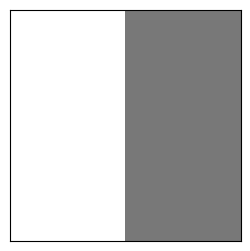

In [13]:
vertical_edge = np.array([[255, 255, 255, 120, 120, 120],
                          [255, 255, 255, 120, 120, 120],
                          [255, 255, 255, 120, 120, 120],
                          [255, 255, 255, 120, 120, 120],
                          [255, 255, 255, 120, 120, 120],
                          [255, 255, 255, 120, 120, 120]])

plt.figure(figsize = (3,3))
plt.xticks([])
plt.yticks([])
plt.imshow(vertical_edge, cmap = 'gray', vmin = 0, vmax = 255);

По центру изображения находится **вертикальный конту**р (vertical image).
Поставим задачу построить новое изображение, на котором светлым оттенком (т.е.
высокими значениями пикселя) будет выделена область, в которой присутствует
резкий переход интенсивности оттенков, и темным оттенком — области, в которых
такого перехода нет.
![](https://drive.google.com/uc?export=view&id=1pL28I3949FW9Pm-Xlv5AeanM4B7wQViN)

Интересно, что для решения этой задачи можно использовать свёртку. Возьмем
новый фильтр и применим его к изображению.

In [14]:
vertical_edge_filter = np.array([[ 1, 0, -1 ],
                                 [ 2, 0, -2 ],
                                 [ 1, 0, -1 ]])

Наложим фильтр на область без перехода оттенка изображения и выполним
расчеты.

$$ 255 \cdot 1 + 255 \cdot 2 + 255 \cdot 1 + 255 \cdot 0 + 255 \cdot 0 + 255 \cdot 0 + $$

$$255 \cdot (-1) + 255 \cdot (-2) + 255 \cdot (-1) = $$

$$ 255 + 510 + 255 + 0 + 0 + 0-255-510-255 = 0 $$

Как мы видим, значения фильтра подобраны таким образом, что при отсутствии
контура (перехода) значения взаимоуничтожаются. Теперь выполним аналогичные
расчеты для области с переходом.

$$ 255 \cdot 1 + 255 \cdot 2 + 255 \cdot 1 + 255 \cdot 0 + 255 \cdot 0 + 255 \cdot 0 + $$

$$120 \cdot (-1) + 120 \cdot (-2) + 120 \cdot (-1) = $$

$$ 255 + 510 + 255 + 0 + 0 + 0-120-240-120 = 540 $$

Здесь контур обнаружен и получившееся значение больше нуля. Выполним свертку
изображения и фильтра.

In [15]:
feature_map = signal.correlate2d(vertical_edge, vertical_edge_filter, mode = 'valid')
feature_map

array([[  0, 540, 540,   0],
       [  0, 540, 540,   0],
       [  0, 540, 540,   0],
       [  0, 540, 540,   0]])

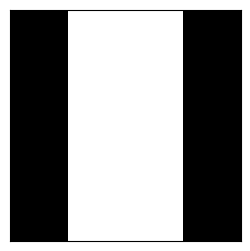

In [16]:
plt.figure(figsize = (3,3))
plt.xticks([])
plt.yticks([])
plt.imshow(feature_map, cmap = 'gray', vmin = 0, vmax = 255);

На карте признаков хорошо видно, где на исходном изображении находится
вертикальный контур.

Интересно, что приведенный выше фильтр ищет переход от светлого оттенка к
темному. Если бы на изображении темный оттенок наоборот переходил в светлый,
то результатом применения такого фильтра были бы отрицательные значения и, как
следствие, выделение контура темным цветом.


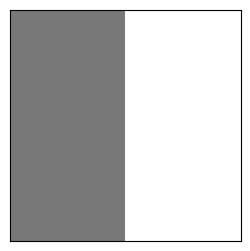

In [17]:
# перевернем картинку относительно оси y
vertical_edge_inv = np.fliplr(vertical_edge)

plt.figure(figsize = (3,3))
plt.xticks([])
plt.yticks([])
plt.imshow(vertical_edge_inv, cmap = 'gray', vmin = 0, vmax = 255);

Выполним свёртку.

In [18]:
feature_map_inv = signal.correlate2d(vertical_edge_inv, vertical_edge_filter, mode = 'valid')
feature_map_inv

array([[   0, -540, -540,    0],
       [   0, -540, -540,    0],
       [   0, -540, -540,    0],
       [   0, -540, -540,    0]])

Посмотрим на изображение.

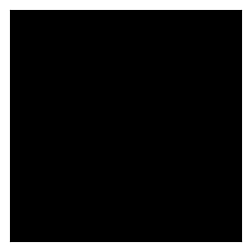

In [19]:
plt.figure(figsize = (3,3))
plt.xticks([])
plt.yticks([])
plt.imshow(feature_map_inv, cmap = 'gray', vmin = 0, vmax = 255);

Для того чтобы на карте признаков получить видимый контур, нужно перевернуть
фильтр.

In [20]:
vertical_edge_filter_inv = np.fliplr(vertical_edge_filter)
vertical_edge_filter_inv

array([[-1,  0,  1],
       [-2,  0,  2],
       [-1,  0,  1]])

In [21]:
signal.correlate2d(vertical_edge_inv, vertical_edge_filter_inv, mode = 'valid')

array([[  0, 540, 540,   0],
       [  0, 540, 540,   0],
       [  0, 540, 540,   0],
       [  0, 540, 540,   0]])

На практике используют только один вертикальный фильтр (любой из двух), а
затем берут модуль получившихся значений или возводят значения в квадрат.

Аналогичным образом можно найти и горизонтальный контур. Для этого
потребуется другой фильтр.

In [22]:
horizontal_edge_filter = np.array([[ 1, 2, 1 ],
                                   [ 0, 0, 0 ],
                                   [ -1, -2, -1 ]])

## Фильтр Собеля
Вместе эти фильтры называются **фильтрами Собеля** (Sobel filter). Их задача
заключается в том, чтобы найти *градиент* (степень изменения) как по
горизонтали, т.е. по оси $x,$ так и по вертикали, то есть по оси $y.$

В самом деле, переход, например, из черного в белое по оси $x$ можно представить
следующим образом.

![](https://drive.google.com/uc?export=view&id=18lKeimgNOB_ahscSNPCOYeEZVsuFcxvo)

Таким образом, математически, речь идет о нахождении двух частных производных
по каждой из осей в определенной точке (для определенного пикселя).

Рассмотрим сегмент исходного изображения размерностью 3 x 3 со значением
интенсивности каждого пикселя $z_i.$

![](https://drive.google.com/uc?export=view&id=17hG_AO2UMITwW7weLLtJN0KXXPKWrXoL)

Оценим градиент пикселя $z_5.$ Зададим частные производные по обеим осям.

$$ g_x = \frac{\partial_f}{\partial_x} = (z_7+2z_8+z_9)-(z_1+2z_2+z_3) $$

$$ g_y = \frac{\partial f}{\partial y} = (z_3+2z_6+z_9)-(z_1+2z_4+z_7) $$

Другими словами, мы оцениваем разность интенсивности пикселей, придавая
больший вес изменению второго столбца и второй строки (отсюда двойка в
формуле).

Если $g_x$ или $g_y$ не равны нулю — это контур, в противном случае — не
контур.

Поскольку, применив один из вертикальных фильтров и один из горизонтальных
фильтров, мы можем получить как положительные, так и отрицательные значения
частных производных, для оценки градиента конкретного пикселя удобно найти его
длину (magnitude).

$$ G = \sqrt{g_x^2+g^2_y} $$

По сути, мы применяем теорему Пифагора.

![](https://drive.google.com/uc?export=view&id=1abrFnsKDn-kmh4mSBW9GGxzOIG6J-W2Y)

Найдем контуры на более реалистичном изображении.

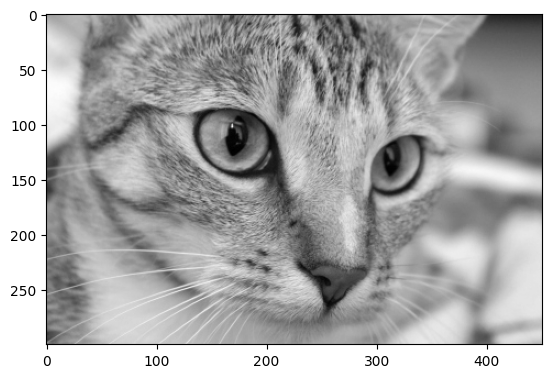

In [23]:
from skimage import data
from skimage.color import rgb2gray
import cv2

# возьмем фотографию кота из библиотеки skimage
cat_img = data.chelsea()
cat_img_gray = rgb2gray(cat_img)
plt.imshow(cat_img_gray, cmap = plt.cm.gray);

Применим фильтр Собеля из библиотеки cv2.

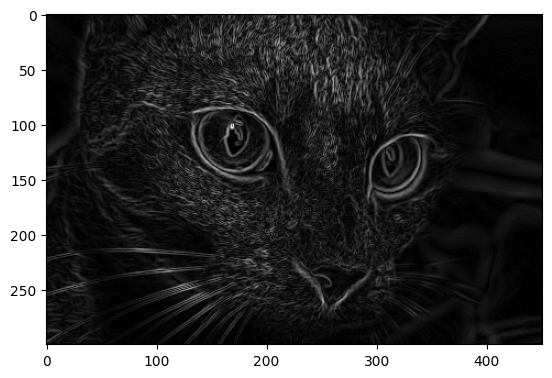

In [24]:
# применим фильтр Собеля из библиотеки cv2
# dx=1, dy=0 указывают на расчет градиента вдоль оси x
# dx=0, dy=1 - соответственно вдоль оси y
# ksize - размер фильтра (kernel size)
sobel_x = cv2.Sobel(cat_img_gray, cv2.CV_64F, dx=1, dy=0, ksize = 3)
sobel_y = cv2.Sobel(cat_img_gray, cv2.CV_64F, dx=0, dy=1, ksize = 3)

# рассчитаем длину вектора градиента
edge_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

plt.imshow(edge_magnitude, cmap = plt.cm.gray);

Добавим, что фильтр Собеля — далеко не единственный фильтр, способный
обнаруживать контуры на изображении.

Выше мы уже использовали** фильтр Прюит**т (Prewitt filter). Кроме этого можно
упомянуть **фильтр Шарра** (Scharr filter).

![](https://drive.google.com/uc?export=view&id=1SJ5_132CqM3eeFt48nUJ20OOaxI-dIec)

Примечание. Как и в случае с фильтром Собеля, эти фильтры также имеют
«версию» для обнаружения горизонтальных контуров.


## Ключевая идея
Обратите внимание, применив фильтр с определенными (выбранными не
случайным образом) значениями, мы можем находить на изображении некоторый
объект.

Можно возразить, что пока что это лишь контур, однако ключевая идея
заключается в том, что если подобрать правильные значения фильтра (то есть
найти веса в процессе обучения модели), то мы сможем находить любые, не
обязательно вертикальные и горизонтальные контуры, а также, собирая эти
контуры вместе, распознавать и другие интересующие нас объекты.

Именно эту задачу и призвана решить свёрточная нейронная сеть. Более того,
математически это возможно, потому что операция свёртки является
дифференцируемой, а значит мы можем найти частные производные функции
ошибки относительно весов модели.

Перейдем к рассмотрению архитектуры свёрточной нейронной сети.

# Свёрточная нейронная сеть. Часть 2

Теперь, когда у нас достаточно знаний об операции свёртки и понятен принцип, согласно которому свёрточная нейросеть может обнаружить интересующий нас объект, самое время перейти к изучению общей архитектуры сети.

## Архитектура свёрточной нейросети

### Подготовка данных

Возьмем уже знакомый нам датасет рукописных цифр MNIST и создадим свёрточную нейросеть-классификатор в библиотеке Keras.

In [25]:
from tensorflow import keras

In [26]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


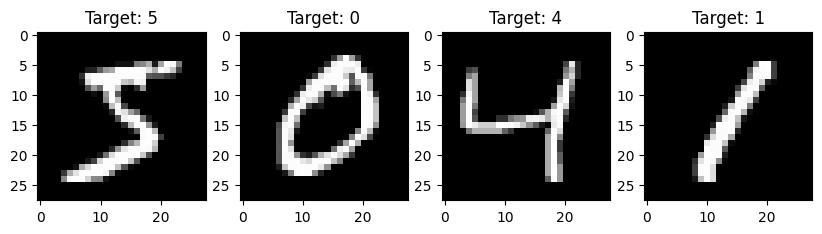

In [27]:
fig, axes = plt.subplots(1, 4, figsize = (10, 3))

for ax, image, label in zip(axes, X_train, y_train):
    ax.imshow(image, cmap = 'gray')
    ax.set_title(f'Target: {label}')

На изображениях выше хорошо видно, что каждая цифра состоит из расположенных под разными углами контуров. Именно эти контуры мы и постараемся запомнить, создав в процессе обучения модели фильтры, похожие на фильтры Собеля.

In [28]:
# приведем изображения к диапазону от -0,5 до 0,5
X_train = (X_train / 255) - 0.5
X_test = (X_test / 255) - 0.5

### Свёрточный слой и подвыборка

Начнем создавать свёрточный слой (convolutional layer):

* мы знаем, что каждая картинка имеет размерность 28 x 28 пикселей;
* пусть фильтр будет размером 3 x 3;
* шаг оставим равным единице; а
* отступ пусть будет нулевым.

В этом случае размерность карты признаков составит 26 x 26.

![](https://drive.google.com/uc?export=view&id=1KqSO6c11ciL80aIOcfGPO8_UXt_f7iDu)

В самом деле, перемещая фильтр с размером шага 1, мы «съедаем» крайние строки и столбцы, тем самым уменьшая оба измерения на два.

Пойдем дальше. Мы уже отметили, что цифры состоят из контуров, причем эти контуры не обязательно вертикальные или горизонтальные, поэтому, скорее всего, нам понадобится больше двух фильтров. Пусть всего фильтров будет восемь.

Заметим, что количество фильтров свёрточного слоя, а также размер шага и отступ — это гиперпараметры, которые настраиваются при обучении модели.

В этом случае мы будем производить свёртку картинки с каждым из восьми фильтров и на выходе ожидаемо получим восемь карт признаков размером 26 x 26.

![](https://drive.google.com/uc?export=view&id=1NWmIoK14IoOUC83bhEANSmQRvM5CvIaG)

Увеличим размерность каждой картинки с двух до трех измерений, то есть 28 x 28 x 1. Это требование библиотеки Keras, и зачем это нужно, станет понятно чуть позже.


In [29]:
# параметр axis функции np.expand_dims() указывает,
# где именно разместить новое измерение
X_train = np.expand_dims(X_train, axis = -1)
X_test = np.expand_dims(X_test, axis = -1)

X_train.shape, X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

## Про количество параметров

Как мы сказали выше, весами в свёрточном слое являются значения фильтров. В нашем случае их 3 x 3 x 8 = 72.

Обратим внимание на важный момент. Количество весов зависит только от размера и количества фильтров, но никак не от размера изображения. Другими словами, мы можем добавить еще один фильтр, и тогда количество весов увеличится до 3 x 3 x 9 = 91, однако если мы возьмем изображение с большей размерностью, скажем 900 x 900 пикселей, количество параметров будет по-прежнему равно 72.

Это свойство свёрточной сети существенно снижает вычислительную затратность обучения модели, а также её склонность к переобучению.

## Функция активации

Результат свёртки, то есть каждое значение тензора карты признаков 26 x 26 x 8 необходимо «пропустить» через функцию активации, чтобы добавить нелинейности нашей функции.

Довольно часто в качестве функции активации используется уже знакомая нам функция **ReLU** или Rectified Linear Unit.

![](https://drive.google.com/uc?export=view&id=10_f6I7yZJHny-ALGOeDS6t22x33LnVTs)

Примечание. Прежде чем передавать значения карты признаков в функцию активации, мы могли бы добавить **смещение** (bias), однако пока для простоты не будем этого делать.

## Операция подвыборки

После свёрточного слоя возникает желание понизить размерность получившегося тензора. Для этой цели применяется **операция подвыборки** (pooling, а также subsampling или downsampling operation). Сам слой при этом называется слоем **подвыборки** (pooling layer).

Рассмотрим несложный пример. Пусть получившаяся карта признаков имеет размерность 4 x 4, и нам бы хотелось сократить размерность в два раза до 2 x 2. Мы могли бы разделить изображение на квадраты, а затем взять из каждого квадрата только максимальное значение.
![](https://drive.google.com/uc?export=view&id=1oIfLv2vJdHq0XQ1BdjtjwuP_G-CBxLoP)

Такая операция называется **подвыборкой по максимальному значению** (max pooling). Идея, помимо понижения размерности, заключается в том, чтобы сохранить высокие значения (ведь высокие значения означают, что признак, например, контур, обнаружен) и отбросить низкие.

Заметим, что в примере выше итоговая размерность после подвыборки по максимальному значению совпадает с операцией свёртки с размерностью фильтра 2 x 2 и размером шага 2. Это знание пригодится нам чуть позже, когда мы будем собирать модель в Keras.

Применим max pooling к картам признаков создаваемой нами нейросети. Каждая карта признаков, таким образом, сократится с 26 x 26 до 13 x 13 пикселей.


![](https://drive.google.com/uc?export=view&id=1LvCqjyhH0f9cZ19tbB3t-tYQetMATxe1)

Дополнительно заметим, что параметры слоя подвыборки не участвуют в обучении модели (расчете обратного распространения ошибки). Их называют **необучаемыми** (non-trainable) параметрами, в отличие **обучаемых** (trainable) параметров свёрточного слоя.

Посмотрим, что было сделано до сих пор:

* мы применили фильтры вначале со случайными, а затем, после обучения, более оптимальными значениями;
* обнаружили признаки; и
* сократили размерность карт признаков с помощью max pooling.

Этот этап называется **извлечением признаков** (feature extraction). Теперь нам хотелось бы сделать прогноз, предсказать, о какой цифре идет речь, то есть перейти к этапу **классификации** (classification).

**«Вытягивание» карт признаков**. Для того чтобы двигаться дальше превратим трехмерный тензор 13 x 13 x 8 в вектор (одномерный массив) из 1 352 значений. За такую операцию будет отвечать специальный слой, который в библиотеке Keras называется Flatten.

## Полносвязный слой

Наконец, получившийся вектор из 1 352 признаков мы соединим с выходным полносвязным слоем из 10 нейронов, по одному для каждого из десяти предсказываемых классов, и пропустим через функцию softmax (смещение опять же пока применять не будем).
![](https://drive.google.com/uc?export=view&id=1-Ll78C9BCvfRF5CE2UB67F5E4T3q63Zr)


По сути здесь мы используем уже знакомую нам полносвязную нейросеть с тем отличием, что у нас остается только входной слой из 1 352 признаков и выходной слой из 10 нейронов. Несложно посчитать, что для полносвязного слоя нам нужно обучить 10 x 1 352 = 13 520 параметров, связывающих каждый нейрон слоя Flatten с каждым нейроном выходного слоя.

Примечание. Здесь будет уместно пояснить, что карта признаков называется так ровно потому, что получившиеся 1 352 значения являются (промежуточными) признаками для дальнейшего обучения классификатора.

### Создание и обучение модели

Мы готовы создать модель в Keras. Приведем код с пояснениями.

In [30]:
model = keras.models.Sequential([
  keras.layers.InputLayer(shape = (28, 28, 1)),
  keras.layers.Conv2D(filters = 8, # количество фильтров
                      kernel_size = 3, # размер фильтра
                      strides = 1, # размер шага
                      padding = 'valid', # тип отступа
                      activation = 'relu', # активация свёрточного слоя
                      use_bias = False), # применение смещения
  keras.layers.MaxPooling2D(pool_size = 2), # размер окна max pooling
  keras.layers.Flatten(),
  keras.layers.Dense(units = 10, # количество нейронов выходного слоя
                     activation = 'softmax', # активация выходного слоя
                     use_bias = False,) # применение смещения
])

model.compile(
  optimizer = 'adam',
  loss = 'categorical_crossentropy',
  metrics = ['accuracy'],
)

model.fit(
  X_train,
  keras.utils.to_categorical(y_train),
  epochs = 3,
  # будем сразу оценивать качество на тестовых данных
  validation_data = (X_test, keras.utils.to_categorical(y_test)),
)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8363 - loss: 0.6133 - val_accuracy: 0.9545 - val_loss: 0.1509
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9633 - loss: 0.1277 - val_accuracy: 0.9641 - val_loss: 0.1152
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9739 - loss: 0.0910 - val_accuracy: 0.9740 - val_loss: 0.0830


In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        13,520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,778 (159.29 KB)

 Trainable params: 13,592 (53.09 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 27,186 (106.20 KB)

Теперь посмотрим, как улучшить полученный результат.

## Улучшение базовой модели

### Количество свёрточных слоёв

Очевидным способом улучшить качество нейросети является увеличение количества свёрточных слоёв. Попробуем применить два слоя, причем в первом используем 32 фильтра, а во втором — 64.

![](https://drive.google.com/uc?export=view&id=1lU9ofHo5Hg64o8DPhIKAi1dQ_ZkuA8VP)

Выбор меньшего количества фильтров для первого слоя и большего для второго не случаен. Первый слой запоминает отдельные фрагменты изображений (контуры), второй и последующие слои собирают из этих фрагментов все более крупные части изображения.

Также говорят, что алгоритм учится создавать **представления** (Representation Learning) данных (например, изображений или текста) из более простых (низкоуровневых) составляющих.

Приведем упрощенный пример работы нейросети, первый слой которой учится определять фрагменты лиц, а второй слой — уже сами лица.

![](https://drive.google.com/uc?export=view&id=1gG4bcdjivZ5mgGKIeNixyMpQ0Q4Tcuzx)

Вполне очевидно, что отдельных фрагментов всегда меньше, чем их комбинаций. Например, из двух фрагментов можно составить $2^2=4$ комбинации. Именно поэтому мы используем меньшее количество фильтров на первых свёрточных слоях.

Теперь поясним приведенную выше схему сети. **Первый свёрточный слой** использует 32 фильтра размером 3 x 3, а также 32 значения смещений по одному для каждого фильтра (значение смещения соответствующего фильтра поэлементно прибавляется к каждому значению фильтра с помощью трансляции (broadcasting)).

Таким образом, получается 3 x 3 x 32 + 32 = 320 обучаемых параметров. Все остальные характеристики первого слоя, то есть опять же размер фильтра 3 x 3, размер окна max pooling 2 x 2, а также получающиеся размерности карты признаков 26 x 26 и операции подвыборки 13 x 13 остаются без изменений.

На втором свёрточном слое мы используем уже 64 фильтра 3 x 3, которые будучи применёнными к каждому из 32 слоев max pooling предыдущего слоя создают карту признаков размерностью 11 x 11 x 64 и требуют 3 x 3 x 32 x 64 = 18 432 обучаемых параметра. Вместе с 64 значениями смещения получается 18 432 + 64 = 18 496 обучаемых параметров.

Операция подвыборки второго слоя с помощью окна размерностью 2 x 2 сокращает каждую из 64 карт признаков до размера 5 x 5.

### Классификация

Получившийся трехмерный тензор второго свёрточного слоя, как и в предыдущем примере, слой Flatten «вытягивает» до вектора, состоящего из 5 x 5 x 64 = 1 600 значений.

Если бы мы сразу, как и в прошлый раз, передали эти значения десяти нейронам выходного слоя, то у нас получилось бы (с учетом 10-ти параметров смещения) 16 000 x 10 + 10 = 16 010 обучаемых значений. Опять же, такое количество параметров может иметь склонность к переобучению.
#### Метод Dropout

В качестве метода регуляризации нейросети используем технику **Dropout** («исключение», «выпадение»). Ее суть заключается в том, чтобы в процессе стохастического градиентного спуска в каждой mini batch исключать/отбрасывать определенный процент $p$
нейронов, обнуляя их значения.

Таким образом, эти нейроны не участвуют в прямом распространении на данной итерации и также не учитываются при расчете градиентов и обновлении весов. На следующей итерации при обучении на новой mini batch исключаются другие нейроны (говорят, что используется новая маска (mask)).
![](https://drive.google.com/uc?export=view&id=1qMHzLEE1Qm-kimXekBDxUQdpl2XFADgr  )

Заметим, что на этапе предсказания Dropout не применяется (в Keras «отключение»
этого слоя происходит автоматически). Поэтому для того чтобы на тестовых
данных не было искажений, в процессе Dropout значения неисключенных нейронов
умножаются на

$$ \frac{1}{1-p}, $$

где $p$ — вероятность исключения одного нейрона (такой метод называют
Inverted Dropout ). Приведем пример. Пусть некоторый слой нейросети состоит из
шести нейронов, а вероятность $p$ равна $0{,}5.$ Тогда каждый из трех
неисключенных нейронов необходимо умножить на $\frac{1}{1-0{,}5}=2.$

![](https://drive.google.com/uc?export=view&id=1l76JGhCHT4R8hGlCBfEV3VG5EX6Y2ss0)

Приведем ссылку на оригинальную статью по методу Dropout (https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf).


## Создание и обучение модели
Напишем код модели в Keras. Вначале зададим архитектуру.

In [32]:
model2 = keras.Sequential(
    [
        keras.layers.InputLayer(shape = (28, 28, 1)),
        keras.layers.Conv2D(filters = 32,
                            # размер фильтра можно задать через кортеж,
                            # указывающий на размерность по каждому измерению
                            kernel_size = (3, 3),
                            activation = 'relu',
                            use_bias = True),
        keras.layers.MaxPooling2D(pool_size = (2, 2)),
        keras.layers.Conv2D(filters = 64,
                            kernel_size = (3, 3),
                            activation = 'relu',
                            use_bias = True),
        keras.layers.MaxPooling2D(pool_size = (2, 2)),
        keras.layers.Flatten(),
        # вероятность исключения нейрона задается через rate
        keras.layers.Dropout(rate = 0.5),
        keras.layers.Dense(10, activation = 'softmax'),
    ]
)

Соберем и обучим модель.

In [33]:
model2.compile(
  optimizer = 'adam',
  loss='categorical_crossentropy',
  metrics=['accuracy'],
)

model2.fit(
  X_train,
  keras.utils.to_categorical(y_train),
  batch_size = 64, # увеличим размер одной batch
  epochs = 10,
  validation_split = 0.1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8136 - loss: 0.6203 - val_accuracy: 0.9783 - val_loss: 0.0745
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9701 - loss: 0.0984 - val_accuracy: 0.9867 - val_loss: 0.0530
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9774 - loss: 0.0726 - val_accuracy: 0.9890 - val_loss: 0.0403
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9821 - loss: 0.0595 - val_accuracy: 0.9907 - val_loss: 0.0360
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9835 - loss: 0.0553 - val_accuracy: 0.9912 - val_loss: 0.0329
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9854 - loss: 0.0459 - val_accuracy: 0.9905 - val_loss: 0.0340
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9859 - loss: 0.0455 - val_accuracy: 0.9913 - val_loss: 0.0318
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9868 - loss: 0.0410 - val_accuracy: 0.

Оценим качество модели на тестовых данных.

In [34]:
print("Test accuracy:", model2.evaluate(X_test,
                                        keras.utils.to_categorical(y_test),
                                        verbose = 0)[1])

Test accuracy: 0.9923999905586243


Также обратите внимание, в первом примере мы использовали разделение на
обучающую и тестовую выборки, а во втором — на обучающие, валидационные и
тестовые данные. Посмотрим на количество параметров.

In [35]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,480 (408.13 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 69,654 (272.09 KB)

Перейдем к работе с цветными изображениями.

## Работа с цветными изобрежениями
### Свёртка по объёму
Особенность работы с цветными изображениями заключается в том, что теперь у
нас есть три матрицы для красного, зеленого и синего **каналов** (RGB channels).
![](https://drive.google.com/uc?export=view&id=1xedn-82Tq-9G7klCj5W6lSfhOZsDswK3)

Как следствие, принято говорить о **высоте** (height), **ширине** (width) и **глубине** (depth) входных данных. Именно по этой причине мы превращали данные MNIST из матрицы в трехмерный тензор 28 x 28 x 1. Черно-белые изображения
рассматриваются как частный случай цветных изображений с одним каналом
(глубиной 1).

Свёртка, называемая в этом случае **свёрткой по объёму** (convolution over volume), будет происходить с также трехмерным фильтром, глубина которого должна
совпадать с глубиной изображения.
![](https://drive.google.com/uc?export=view&id=1SDt8YoZn08XE_q6cNVRWQh0HmZTjEqQN)

Технически, наложив трехмерный фильтр на, скажем, левый верхний угол тензора
изображения, мы поэлементно перемножим каждое значение изображения с
каждым значением фильтра и сложим произведения.

![](https://drive.google.com/uc?export=view&id=1KreVB3M0AnGM6qDqXLXuiWEl29oP8I2_)

Например, если фильтр имеет размерность 3 x 3 x 3 мы поэлементно перемножим
каждый из 27 элементов выбранного сегмента изображения с соответствующим
элементом фильтра и сложим результаты. Эта операция и даст нам один элемент
карты признаков. Несложно увидеть, что свёртка по объёму превращает
трехмерные объекты в двумерные.

В случае нескольких фильтров каждый из них создаст двумерную карту признаков,
которые вместе сформируют трехмерный тензор.
![](https://drive.google.com/uc?export=view&id=1CukCANJw1jcb8PtMZ-Ti8toKsW9BFEuf)

## Калькулятор
Убедимся в правильности расчетов с помощью онлайн-калькулятора https://madebyollin.github.io/convnet-calculator/

![](https://drive.google.com/uc?export=view&id=1-tJIkoZZ_C5KMNrj9QJKXPWflrrvkcc3)

**Немного терминологии. **Поясним, что размер фильтра в этом калькуляторе
обозначен через термин **«пространственные границы»** (spatial extent). Также для
характеристики площади в пикселях, покрываемой фильтром, говорят о
**рецептивном поле** (receptive field) нейрона.
## CIFAR-10
Перейдем к созданию уже немного более сложной сети-классификатора цветных
изображений из датасета CIFAR-10.

Этот набор данных содержит 60 000 изображений размером 32 x 32 x 3, на которых
представлены объекты следующих десяти классов.
![](https://drive.google.com/uc?export=view&id=1p_rwhIir2sTAqcbzheFNX2UoEOEJ1iQx)

Импортируем библиотеку и посмотрим на первые изображения.

In [36]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [37]:
X_train.shape, X_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

In [38]:
y_train.shape, y_test.shape

((50000, 1), (10000, 1))

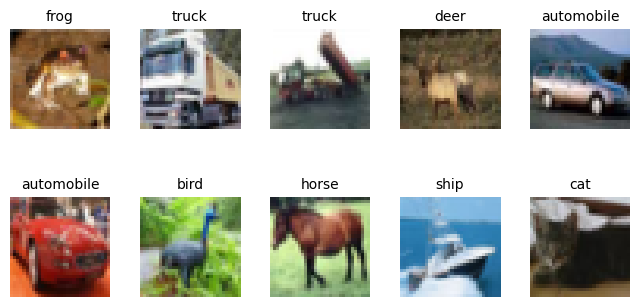

In [39]:
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer',
          'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(nrows = 2, ncols = 5, figsize = (8, 4))
axes = axes.ravel()
for i in np.arange(0, 10):
    axes[i].imshow(X_train[i])
    axes[i].axis('off')
    axes[i].set_title(labels[np.squeeze(y_train)[i]], fontsize = 10)

plt.subplots_adjust(wspace = 0.3)

Примечание. Подробный разбор применяемых для визуализации изображений
функций и методов можно найти в нашем курсе.

In [40]:
X_train = (X_train / 255) - 0.5
X_test = (X_test / 255) - 0.5

## Batch Normalization (BN)
Одной из сложностей, возникающих при обучении нейросети является так
называемый **внутренний ковариационный сдвиг** (internal covariate shift), явление
при котором от одной итерации к другой значения нейронов данного слоя могут
существенно изменяться в зависимости от используемых данных (batches), что (1)
дестабилизирует обучение (усложняет сходимость) и в конечном итоге (2)
негативно сказывается на обобщающей способности алгоритма.

Как следствие, возникла идея на этапе **обучения** для *каждой карты признаков*
(каждого канала) нормализовать (или, говоря более точно, стандартизовать)
значения batch $B,$ т.е. привести распределение к нулевому среднему и
единичному СКО с помощью выборочных среднего $\hat{\mu}_B$ и СКО
$\hat{\sigma}_B.$

При этом для того чтобы приблизить нормализованное распределение к
фактическому, результат «восстанавливается», т.е. масштабируется и сдвигается на
величину двух обучаемых параметров $\gamma$ и $\beta.$

$$ B_{\text{norm}} = \gamma \odot \frac{B-\hat{\mu}_B}
{\hat{\sigma}_B+\varepsilon} + \beta $$

где $\varepsilon$ — небольшая константа, предотвращающая деление на ноль, а
$\odot$ — произведение Адамара. Таким образом, для того чтобы нормализовать
тензор размерностью, например, 28 x 28 x 64 потребуется два необучаемых
$\hat{\mu}_B, \hat{\sigma}_B$ и два обучаемых $\gamma, \beta$ параметра для
каждого из 64 каналов или 4 x 64 = 256 параметров.

На этапе предсказания данные нормализуются через скользящее среднее и
скользящее СКО, полученные при обучении, а затем преобразуются с помощью
выученных значений γ и β.

Важным вопросом является выбор этапа, на котором следует применять batch
normalization. Преобразование данных следует использовать после операции
свёртки и до применения функции активации (например, ReLU).

При этом многие исследователи и, в частности, создатель Keras Франсуа Шолле
(François Chollet) говорят о том, что BN стоит использовать уже после ReLU.
Перейдем к созданию нейросети для классификации изображений из CIFAR-10.

## Архитектура сети
Сеть будет состоять из трёх свёрточных слоёв, причём первый и третий слои будут
состоять из свёртки, batch normalization и подвыборки, а второй слой — только из
свёртки и batch normalization.

***Примечание.*** Здесь стоит добавить, что при обсуждении архитектуры CNN, слоями называют как совокупность, например, свёрточного слоя и слоя подвыборки, так и отдельно свёрточный слой или слой max pooling.

Зададим размерности тензоров и рассчитаем количество параметров нейросети.
Начнем со свёрточных слоёв. Размер входного изображения составляет 32 x 32 x 3 и
при размере одного из 64 фильтров 5 x 5 x 3 результатом первого свёрточного слоя
будет тензор признаков 28 x 28 x 64 (размер шага 1).

При этом потребуется 5 x 5 x 3 x 64 + 64 = 4 864 параметра свёртки и 4 x 64 = 256 параметров batch normalization. Еще раз обратим внимание, что только половина из них, то есть 256 / 2 = 128 являются обучаемыми.

Результатом max pooling (размер окна 2 x 2, шаг 2) будет тензор 14 x 14 x 64.
![](https://drive.google.com/uc?export=view&id=1E_FGnM3jdWnEpMsfgRzI1wV2rI32kzDU)

Поясним, что #f — количество фильтров, f — размер фильтра, s — stride, то есть
размер шага.

Во втором свёрточном слое при размере одного из 128 фильтров 3 x 3 x 3
результатом первого сверточного слоя будет тензор признаков 12 x 12 x 128 (размер
шага 1). Для свёртки потребуется 3 x 3 x 64 x 128 + 128 = 73 856 параметров, для
BN ㅡ 4 x 128 = 512 параметров. Max pooling здесь не применяется.

В третьем слое будет уже 256 фильтров 3 x 3 x 3 и результатом станет тензор 10 x
10 x 256 (размер шага 1). Потребуется 3 x 3 x 128 x 256 + 256 = 295 168 параметров
свёртки и 4 x 128 = 1 024 BN. После max pooling (размер окна 2 x 2, шаг 2) получим
тензор 5 x 5 x 256.
![](https://drive.google.com/uc?export=view&id=1NIe4UOhOD011ndTpz9uU9hACzkPTDLz4)

Таким образом, общее количество параметров свёртки составит 4 864 + 73 856 +
295 168 = 373 888, а параметров BN 256 + 512 + 1 024 = 1 792, из которых половина
или 896 будут необучаемыми.

Перейдем к полносвязным слоям. Слой Flatten состоит из 6 400 нейронов, первый
полносвязный слой — из 1 024. Количество весов 6 400 x 1 024 + 1 024 = 6 554 624.
Между последующими слоями (см. схему ниже) потребуется 1 024 x 1 024 + 1 024 =
1 049 600, 1 024 x 512 + 512 = 524 800 и наконец 512 x 10 + 10 = 5 130 параметров.

![](https://drive.google.com/uc?export=view&id=1Q_lrfmXPMYpGmV5YTZf3zAlqJu-MA5_J)

Таким образом, в полносвязных слоях будет 6 554 624 + 1 049 600 + 524 800 + 5 130 = 8 134 154 параметров. Общее же количество обучаемых параметров составит 373
888 + 896 + 8 134 154 = 8 508 938.

Также заметим, что существуют более эффективные (и более сложные)
архитектуры свёрточных сетей. Нашей целью сегодня было познакомиться с
основными инструментами таких моделей и продемонстрировать общие принципы
построения CNN.


## Создание и обучение модели

Зададим архитектуру в Keras.

In [41]:
model3 = keras.Sequential(
    [
        keras.layers.InputLayer(shape = (32, 32, 3)),

        keras.layers.Conv2D(filters = 64,
                            kernel_size = (5, 5),
                            strides = (1, 1),
                            padding = 'valid',
                            activation = 'relu',
                            use_bias = True),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D(pool_size = (2, 2),
                                  strides = 2),

        keras.layers.Conv2D(filters = 128,
                            kernel_size = (3, 3),
                            strides = (1, 1),
                            padding = 'valid',
                            activation = 'relu',
                            use_bias = True),
        keras.layers.BatchNormalization(),

        keras.layers.Conv2D(filters = 256,
                            kernel_size = (3, 3),
                            strides = (1, 1),
                            padding = 'valid',
                            activation = 'relu',
                            use_bias = True),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D(pool_size = (2, 2),
                                  strides = 2),

        keras.layers.Flatten(),
        keras.layers.Dropout(rate = 0.5),
        keras.layers.Dense(1024, activation = 'relu'),
        keras.layers.Dropout(rate = 0.5),
        keras.layers.Dense(1024, activation = 'relu'),
        keras.layers.Dropout(rate = 0.5),
        keras.layers.Dense(512, activation = 'relu'),

        keras.layers.Dense(10, activation = 'softmax'),
    ]
)

Соберём и обучим модель.

In [42]:
model3.compile(
  optimizer = keras.optimizers.Adam(learning_rate = 0.001),
  loss = 'categorical_crossentropy',
  metrics = ['accuracy'],
)

model3.fit(
  X_train,
  keras.utils.to_categorical(y_train),
  batch_size = 64,
  epochs = 10,
  validation_split = 0.1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.2982 - loss: 2.1395 - val_accuracy: 0.5250 - val_loss: 1.3206
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5288 - loss: 1.3215 - val_accuracy: 0.6162 - val_loss: 1.1020
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6182 - loss: 1.1047 - val_accuracy: 0.6738 - val_loss: 0.9531
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6730 - loss: 0.9515 - val_accuracy: 0.7068 - val_loss: 0.8606
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.7107 - loss: 0.8372 - val_accuracy: 0.7442 - val_loss: 0.7624
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.7402 - loss: 0.7710 - val_accuracy: 0.7544 - val_loss: 0.7175
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.7603 - loss: 0.7073 - val_accuracy: 0.7788 - val_loss: 0.6507
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.7819 - loss: 0.6396 - val_ac

In [43]:
print("Test accuracy:", model3.evaluate(X_test,
                                        keras.utils.to_categorical(y_test),
                                        verbose = 0)[1])

Test accuracy: 0.777400016784668


Дополнительно сверимся с правильностью расчетов параметров модели.

In [44]:
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     6,554,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,527,712 (97.38 MB)

 Trainable params: 8,508,938 (32.46 MB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 17,017,878 (64.92 MB)

Теперь создадим свёрточную нейросеть без использования Keras.